In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold

In [2]:
feature_df = pd.read_csv("week5_ecg_features.csv")

print("Dataset shape:", feature_df.shape)

print("\nRecords by dataset:")
print(feature_df["dataset"].value_counts())

print("\nLabels:")
print(feature_df["label"].value_counts())

print("\nNumber of unique patients:")
print(feature_df["patient_id"].nunique())

print("\nRepeated patient IDs:")
print(feature_df["patient_id"].duplicated().sum())

feature_df.head()

Dataset shape: (2100, 15)

Records by dataset:
dataset
SaMi-Trop    1600
PTB-XL        500
Name: count, dtype: int64

Labels:
label
1    1600
0     500
Name: count, dtype: int64

Number of unique patients:
2099

Repeated patient IDs:
1


,mean_rr_ms,sdnn_ms,rmssd_ms,heart_rate_bpm,qrs_duration_ms,signal_mean,signal_std,signal_max,signal_min,record_id,patient_id,dataset,age,sex,label
0,1109.583333,22.550868,31.898276,54.092802,132.5,0.000231,0.103140,0.602718,-0.382984,100726,samitrop_100726,SaMi-Trop,64,Male,1
1,1046.666667,7.011895,12.399597,57.326992,220.0,-0.000946,0.106088,0.476027,-0.458143,101191,samitrop_101191,SaMi-Trop,49,Male,1
2,949.285714,5.721721,6.373774,63.207383,115.0,0.003463,0.214373,0.894476,-0.502218,101193,samitrop_101193,SaMi-Trop,68,Female,1
3,985.416667,10.418333,8.587782,60.893648,182.5,0.001000,0.126772,0.538971,-0.332201,101282,samitrop_101282,SaMi-Trop,70,Female,1
4,918.571429,12.571226,16.007811,65.329221,175.0,0.001624,0.286154,1.751559,-0.493912,101842,samitrop_101842,SaMi-Trop,49,Female,1


In [3]:
feature_columns = [
    "mean_rr_ms",
    "sdnn_ms",
    "rmssd_ms",
    "heart_rate_bpm",
    "qrs_duration_ms",
    "signal_mean",
    "signal_std",
    "signal_max",
    "signal_min",
    "age",
    "sex"
]

X = feature_df[feature_columns].copy()
y = feature_df["label"].copy()
groups = feature_df["patient_id"].copy()

group_kfold = GroupKFold(n_splits=5)

print("Number of records:", len(X))
print("Number of unique patients:", groups.nunique())
print("Number of folds:", group_kfold.get_n_splits())

for fold, (train_indices, val_indices) in enumerate(
    group_kfold.split(X, y, groups=groups),
    start=1
):
    y_train_fold = y.iloc[train_indices]
    y_val_fold = y.iloc[val_indices]

    train_groups = set(groups.iloc[train_indices])
    val_groups = set(groups.iloc[val_indices])

    print(f"\nFold {fold}")
    print("Training records:", len(train_indices))
    print("Validation records:", len(val_indices))
    print("Training labels:", y_train_fold.value_counts().to_dict())
    print("Validation labels:", y_val_fold.value_counts().to_dict())
    print("Patient overlap:", len(train_groups & val_groups))

Number of records: 2100
Number of unique patients: 2099
Number of folds: 5

Fold 1
Training records: 1680
Validation records: 420
Training labels: {1: 1281, 0: 399}
Validation labels: {1: 319, 0: 101}
Patient overlap: 0

Fold 2
Training records: 1680
Validation records: 420
Training labels: {1: 1280, 0: 400}
Validation labels: {1: 320, 0: 100}
Patient overlap: 0

Fold 3
Training records: 1680
Validation records: 420
Training labels: {1: 1280, 0: 400}
Validation labels: {1: 320, 0: 100}
Patient overlap: 0

Fold 4
Training records: 1680
Validation records: 420
Training labels: {1: 1280, 0: 400}
Validation labels: {1: 320, 0: 100}
Patient overlap: 0

Fold 5
Training records: 1680
Validation records: 420
Training labels: {1: 1279, 0: 401}
Validation labels: {1: 321, 0: 99}
Patient overlap: 0


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

numeric_features = [
    "mean_rr_ms",
    "sdnn_ms",
    "rmssd_ms",
    "heart_rate_bpm",
    "qrs_duration_ms",
    "signal_mean",
    "signal_std",
    "signal_max",
    "signal_min",
    "age"
]

categorical_features = ["sex"]

numeric_for_logistic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_for_forest = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_processing = Pipeline([
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

logistic_preprocessor = ColumnTransformer([
    ("numeric", numeric_for_logistic, numeric_features),
    ("categorical", categorical_processing, categorical_features)
])

forest_preprocessor = ColumnTransformer([
    ("numeric", numeric_for_forest, numeric_features),
    ("categorical", categorical_processing, categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

random_forest_model = Pipeline([
    ("preprocessor", forest_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("Week 5 models recreated.")

Week 5 models recreated.


In [5]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def challenge_score(y_true, probabilities, alpha=0.05):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    number_selected = int(np.floor(alpha * len(y_true)))

    if number_selected == 0:
        return 0.0

    sorted_probabilities = np.sort(probabilities)[::-1]
    cutoff_probability = sorted_probabilities[number_selected - 1]

    above_cutoff = probabilities > cutoff_probability
    tied_at_cutoff = probabilities == cutoff_probability

    selected_above = above_cutoff.sum()
    remaining_places = number_selected - selected_above

    positives_above = y_true[above_cutoff].sum()

    number_tied = tied_at_cutoff.sum()
    positives_tied = y_true[tied_at_cutoff].sum()

    expected_tied_positives = (
        remaining_places * positives_tied / number_tied
    )

    total_positives = y_true.sum()

    return (
        positives_above + expected_tied_positives
    ) / total_positives


def cross_validate_model(model, X, y, groups, cv):
    fold_results = []

    oof_predictions = np.zeros(len(y), dtype=int)
    oof_probabilities = np.zeros(len(y), dtype=float)

    for fold, (train_indices, val_indices) in enumerate(
        cv.split(X, y, groups=groups),
        start=1
    ):
        fold_model = clone(model)

        X_train = X.iloc[train_indices]
        X_val = X.iloc[val_indices]

        y_train = y.iloc[train_indices]
        y_val = y.iloc[val_indices]

        fold_model.fit(X_train, y_train)

        probabilities = fold_model.predict_proba(X_val)[:, 1]
        predictions = (probabilities >= 0.5).astype(int)

        oof_predictions[val_indices] = predictions
        oof_probabilities[val_indices] = probabilities

        fold_results.append({
            "Fold": fold,
            "Accuracy": accuracy_score(y_val, predictions),
            "Precision": precision_score(y_val, predictions),
            "Sensitivity": recall_score(
                y_val, predictions, pos_label=1
            ),
            "Specificity": recall_score(
                y_val, predictions, pos_label=0
            ),
            "F1": f1_score(y_val, predictions),
            "AUROC": roc_auc_score(y_val, probabilities),
            "Challenge Score": challenge_score(
                y_val, probabilities
            )
        })

    return (
        pd.DataFrame(fold_results),
        oof_predictions,
        oof_probabilities
    )

In [6]:
logistic_cv_results, logistic_oof_predictions, logistic_oof_probabilities = (
    cross_validate_model(
        logistic_model,
        X,
        y,
        groups,
        group_kfold
    )
)

forest_cv_results, forest_oof_predictions, forest_oof_probabilities = (
    cross_validate_model(
        random_forest_model,
        X,
        y,
        groups,
        group_kfold
    )
)

print("Logistic Regression:")
display(logistic_cv_results.round(4))

print("\nRandom Forest:")
display(forest_cv_results.round(4))

Logistic Regression:


,Fold,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,1,0.7429,0.9489,0.6991,0.8812,0.8051,0.8704,0.0658
1,2,0.7619,0.9365,0.7375,0.8400,0.8252,0.8651,0.0656
2,3,0.7690,0.9339,0.7500,0.8300,0.8319,0.8445,0.0594
3,4,0.8119,0.9382,0.8062,0.8300,0.8672,0.8932,0.0656
4,5,0.7929,0.9301,0.7882,0.8081,0.8533,0.8665,0.0654



Random Forest:


,Fold,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,1,0.8548,0.8839,0.9310,0.6139,0.9069,0.9003,0.0658
1,2,0.8619,0.8808,0.9469,0.5900,0.9127,0.9200,0.0656
2,3,0.8500,0.8791,0.9312,0.5900,0.9044,0.9034,0.0656
3,4,0.8690,0.8754,0.9656,0.5600,0.9183,0.9241,0.0656
4,5,0.8810,0.8950,0.9564,0.6364,0.9247,0.9190,0.0654


In [7]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Sensitivity",
    "Specificity",
    "F1",
    "AUROC",
    "Challenge Score"
]

def summarize_cv_results(results_dict):
    rows = []

    for model_name, results in results_dict.items():
        row = {"Model": model_name}

        for metric in metric_columns:
            mean = results[metric].mean()
            std = results[metric].std(ddof=1)

            row[metric] = f"{mean:.4f} ± {std:.4f}"

        rows.append(row)

    return pd.DataFrame(rows)


baseline_summary = summarize_cv_results({
    "Logistic Regression": logistic_cv_results,
    "Random Forest": forest_cv_results
})

baseline_summary

,Model,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,Logistic Regression,0.7757 ± 0.0270,0.9375 ± 0.0071,0.7562 ± 0.0424,0.8379 ± 0.0269,0.8365 ± 0.0243,0.8679 ± 0.0173,0.0644 ± 0.0028
1,Random Forest,0.8633 ± 0.0122,0.8828 ± 0.0075,0.9462 ± 0.0153,0.5980 ± 0.0287,0.9134 ± 0.0083,0.9134 ± 0.0107,0.0656 ± 0.0001


In [8]:
import xgboost as xgb
from xgboost import XGBClassifier

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [9]:
xgboost_model = Pipeline([
    ("preprocessor", forest_preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgboost_cv_results, xgboost_oof_predictions, xgboost_oof_probabilities = (
    cross_validate_model(
        xgboost_model,
        X,
        y,
        groups,
        group_kfold
    )
)

print("XGBoost:")
display(xgboost_cv_results.round(4))

XGBoost:


,Fold,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,1,0.8548,0.8957,0.9154,0.6634,0.9054,0.9092,0.0658
1,2,0.8738,0.8985,0.9406,0.6600,0.9191,0.9272,0.0656
2,3,0.8786,0.8968,0.9500,0.6500,0.9226,0.9199,0.0656
3,4,0.8690,0.8886,0.9469,0.6200,0.9168,0.9244,0.0656
4,5,0.8857,0.9075,0.9470,0.6869,0.9268,0.9242,0.0654


In [10]:
default_results_summary = summarize_cv_results({
    "Logistic Regression": logistic_cv_results,
    "Random Forest": forest_cv_results,
    "XGBoost": xgboost_cv_results
})

default_results_summary


,Model,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,Logistic Regression,0.7757 ± 0.0270,0.9375 ± 0.0071,0.7562 ± 0.0424,0.8379 ± 0.0269,0.8365 ± 0.0243,0.8679 ± 0.0173,0.0644 ± 0.0028
1,Random Forest,0.8633 ± 0.0122,0.8828 ± 0.0075,0.9462 ± 0.0153,0.5980 ± 0.0287,0.9134 ± 0.0083,0.9134 ± 0.0107,0.0656 ± 0.0001
2,XGBoost,0.8724 ± 0.0116,0.8974 ± 0.0068,0.9400 ± 0.0142,0.6560 ± 0.0243,0.9181 ± 0.0081,0.9210 ± 0.0071,0.0656 ± 0.0001


In [11]:
from sklearn.model_selection import RandomizedSearchCV

xgboost_param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [2, 3, 4, 5, 6],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgboost_model,
    param_distributions=xgboost_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=group_kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X,
    y,
    groups=groups
)

print("\nBest parameters:")
print(random_search.best_params_)

print("\nBest cross-validation AUROC:")
print(round(random_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 3, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 0.9}

Best cross-validation AUROC:
0.9306


In [12]:
tuned_xgboost_model = random_search.best_estimator_

tuned_xgboost_cv_results, tuned_xgboost_oof_predictions, tuned_xgboost_oof_probabilities = (
    cross_validate_model(
        tuned_xgboost_model,
        X,
        y,
        groups,
        group_kfold
    )
)

print("Tuned XGBoost:")
display(tuned_xgboost_cv_results.round(4))

Tuned XGBoost:


,Fold,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,1,0.8714,0.9128,0.9185,0.7228,0.9156,0.9241,0.0658
1,2,0.8833,0.9094,0.9406,0.7000,0.9247,0.9406,0.0656
2,3,0.8833,0.9144,0.9344,0.7200,0.9243,0.9262,0.0656
3,4,0.8905,0.9077,0.9531,0.6900,0.9299,0.9310,0.0656
4,5,0.8929,0.9059,0.9595,0.6768,0.9319,0.9312,0.0654


In [13]:
results_summary = summarize_cv_results({
    "Logistic Regression": logistic_cv_results,
    "Random Forest": forest_cv_results,
    "XGBoost": xgboost_cv_results,
    "XGBoost (Tuned)": tuned_xgboost_cv_results
})

results_summary

,Model,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,Logistic Regression,0.7757 ± 0.0270,0.9375 ± 0.0071,0.7562 ± 0.0424,0.8379 ± 0.0269,0.8365 ± 0.0243,0.8679 ± 0.0173,0.0644 ± 0.0028
1,Random Forest,0.8633 ± 0.0122,0.8828 ± 0.0075,0.9462 ± 0.0153,0.5980 ± 0.0287,0.9134 ± 0.0083,0.9134 ± 0.0107,0.0656 ± 0.0001
2,XGBoost,0.8724 ± 0.0116,0.8974 ± 0.0068,0.9400 ± 0.0142,0.6560 ± 0.0243,0.9181 ± 0.0081,0.9210 ± 0.0071,0.0656 ± 0.0001
3,XGBoost (Tuned),0.8843 ± 0.0084,0.9100 ± 0.0035,0.9412 ± 0.0161,0.7019 ± 0.0196,0.9253 ± 0.0063,0.9306 ± 0.0064,0.0656 ± 0.0001


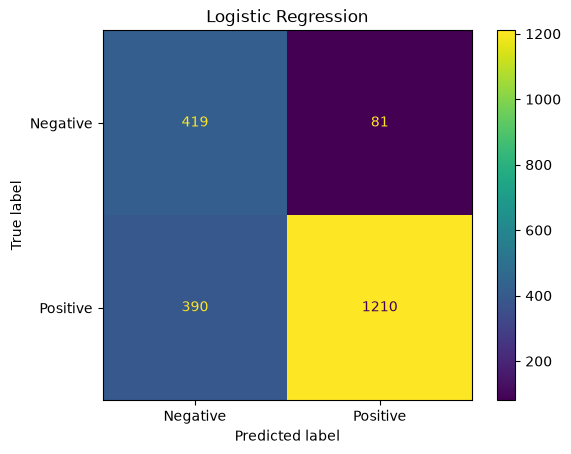

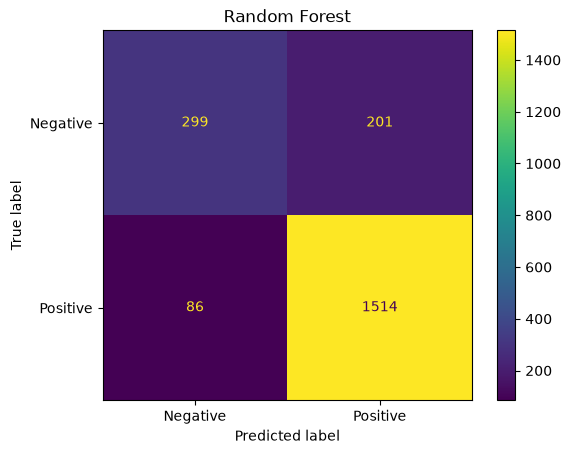

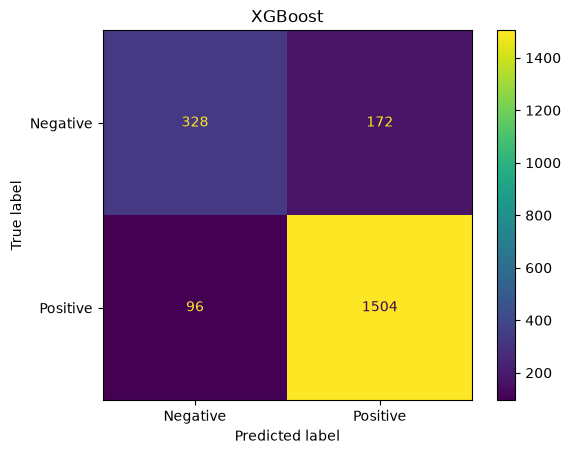

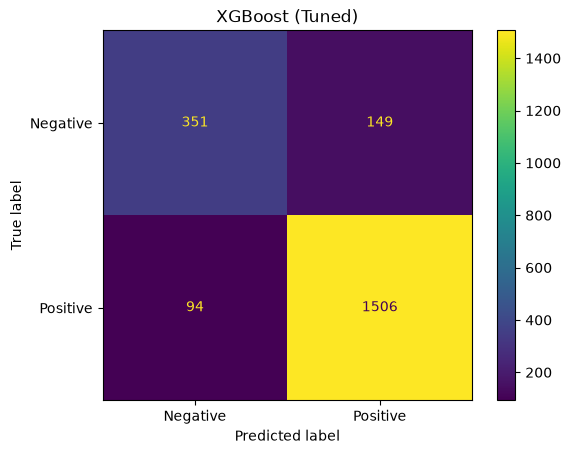

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

models_for_confusion = {
    "Logistic Regression": logistic_oof_predictions,
    "Random Forest": forest_oof_predictions,
    "XGBoost": xgboost_oof_predictions,
    "XGBoost (Tuned)": tuned_xgboost_oof_predictions
}

for model_name, predictions in models_for_confusion.items():
    cm = confusion_matrix(y, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )

    disp.plot()
    plt.title(model_name)
    plt.show()

In [15]:
for model_name, predictions in models_for_confusion.items():
    tn, fp, fn, tp = confusion_matrix(y, predictions).ravel()

    print(f"\n{model_name}")
    print("Correctly predicted negatives (TN):", tn)
    print("Missed positives (FN):", fn)
    print("Correctly predicted positives (TP):", tp)
    print("Incorrectly predicted positives (FP):", fp)


Logistic Regression
Correctly predicted negatives (TN): 419
Missed positives (FN): 390
Correctly predicted positives (TP): 1210
Incorrectly predicted positives (FP): 81

Random Forest
Correctly predicted negatives (TN): 299
Missed positives (FN): 86
Correctly predicted positives (TP): 1514
Incorrectly predicted positives (FP): 201

XGBoost
Correctly predicted negatives (TN): 328
Missed positives (FN): 96
Correctly predicted positives (TP): 1504
Incorrectly predicted positives (FP): 172

XGBoost (Tuned)
Correctly predicted negatives (TN): 351
Missed positives (FN): 94
Correctly predicted positives (TP): 1506
Incorrectly predicted positives (FP): 149


Model comparison

Patient level 5-fold cross-validation showed clear differences between the models. Logistic Regression had the highest precision and specificity, correctly identifying 419 negative records, but it missed 390 positive records and had the lowest sensitivity. Random Forest had the highest sensitivity and missed only 86 positives, although its specificity was lower and it correctly identified only 299 negatives. XGBoost had the best overall balance between sensitivity and specificity. After tuning, XGBoost achieved the highest accuracy, F1 score, and AUROC, while correctly identifying 351 negatives and missing 94 positives. This implies that tuned XGBoost had the best overall performance across the standard evaluation metrics. For the Challenge score, Random Forest, XGBoost, and tuned XGBoost were tied at 0.0656 ± 0.0001, while Logistic Regression was a bit lower at 0.0644 ± 0.0028. Therefore, the ranking of the models changes depending on the metric. Random Forest had the best sensitivity, Logistic Regression had the best specificity and precision, while tuned XGBoost performed best on accuracy, F1, and AUROC.

In [16]:
logistic_unweighted = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

forest_unweighted = Pipeline([
    ("preprocessor", forest_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [17]:
logistic_unweighted_results, _, _ = cross_validate_model(
    logistic_unweighted,
    X,
    y,
    groups,
    group_kfold
)

forest_unweighted_results, _, _ = cross_validate_model(
    forest_unweighted,
    X,
    y,
    groups,
    group_kfold
)

class_weight_comparison = summarize_cv_results({
    "Logistic Regression (Unweighted)": logistic_unweighted_results,
    "Logistic Regression (Balanced)": logistic_cv_results,
    "Random Forest (Unweighted)": forest_unweighted_results,
    "Random Forest (Balanced)": forest_cv_results
})

class_weight_comparison

,Model,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC,Challenge Score
0,Logistic Regression (Unweighted),0.8338 ± 0.0122,0.8598 ± 0.0069,0.9343 ± 0.0217,0.5118 ± 0.0379,0.8954 ± 0.0089,0.8714 ± 0.0170,0.0644 ± 0.0028
1,Logistic Regression (Balanced),0.7757 ± 0.0270,0.9375 ± 0.0071,0.7562 ± 0.0424,0.8379 ± 0.0269,0.8365 ± 0.0243,0.8679 ± 0.0173,0.0644 ± 0.0028
2,Random Forest (Unweighted),0.8714 ± 0.0158,0.8948 ± 0.0070,0.9419 ± 0.0154,0.6461 ± 0.0186,0.9177 ± 0.0106,0.9155 ± 0.0109,0.0656 ± 0.0001
3,Random Forest (Balanced),0.8633 ± 0.0122,0.8828 ± 0.0075,0.9462 ± 0.0153,0.5980 ± 0.0287,0.9134 ± 0.0083,0.9134 ± 0.0107,0.0656 ± 0.0001


Class weighting changed the sensitivity/specificity tradeoff differently across the models. For Logistic Regression, using `class_weight="balanced"` increased specificity from 0.5118 to 0.8379, but sensitivity decreased from 0.9343 to 0.7562. This means the balanced model became much better at identifying negative records, but missed more positive cases.

This happened because positive records are the majority in this dataset, so balanced class weights place relatively more importance on the smaller negative class.

For Random Forest, the effect was smaller. Sensitivity increased slightly from 0.9419 to 0.9462, while specificity decreased from 0.6461 to 0.5980. The Challenge score was essentially unchanged for both models, showing that class weighting mainly affected the balance between positive and negative predictions rather than the Challenge metric.

In [19]:
learning_rows = []

fractions = [0.25, 0.50, 0.75, 1.00]

for fold, (train_indices, val_indices) in enumerate(
    group_kfold.split(X, y, groups=groups),
    start=1
):
    train_group_info = pd.DataFrame({
        "patient_id": groups.iloc[train_indices].to_numpy(),
        "label": y.iloc[train_indices].to_numpy()
    }).drop_duplicates("patient_id")

    positive_groups = train_group_info.loc[
        train_group_info["label"] == 1,
        "patient_id"
    ].to_numpy()

    negative_groups = train_group_info.loc[
        train_group_info["label"] == 0,
        "patient_id"
    ].to_numpy()

    for fraction_number, fraction in enumerate(fractions):
        rng = np.random.default_rng(
            42 + fold * 100 + fraction_number
        )

        n_positive = max(
            1,
            int(round(fraction * len(positive_groups)))
        )

        n_negative = max(
            1,
            int(round(fraction * len(negative_groups)))
        )

        selected_positive = rng.choice(
            positive_groups,
            size=n_positive,
            replace=False
        )

        selected_negative = rng.choice(
            negative_groups,
            size=n_negative,
            replace=False
        )

        selected_groups = np.concatenate([
            selected_positive,
            selected_negative
        ])

        subset_mask = groups.iloc[train_indices].isin(
            selected_groups
        ).to_numpy()

        subset_indices = train_indices[subset_mask]

        model = clone(tuned_xgboost_model)

        model.fit(
            X.iloc[subset_indices],
            y.iloc[subset_indices]
        )

        train_probabilities = model.predict_proba(
            X.iloc[subset_indices]
        )[:, 1]

        val_probabilities = model.predict_proba(
            X.iloc[val_indices]
        )[:, 1]

        learning_rows.append({
            "Fraction": fraction,
            "Training Records": len(subset_indices),
            "Training AUROC": roc_auc_score(
                y.iloc[subset_indices],
                train_probabilities
            ),
            "Validation AUROC": roc_auc_score(
                y.iloc[val_indices],
                val_probabilities
            )
        })


learning_results = pd.DataFrame(learning_rows)

learning_summary = (
    learning_results
    .groupby("Fraction")
    .agg({
        "Training Records": "mean",
        "Training AUROC": ["mean", "std"],
        "Validation AUROC": ["mean", "std"]
    })
)

learning_summary

Training Records Training AUROC           Validation AUROC          
                     mean           mean       std             mean       std
Fraction                                                                     
0.25                420.2       0.999956  0.000068         0.870928  0.016388
0.50                840.2       0.999274  0.000100         0.906332  0.010199
0.75               1260.0       0.996317  0.001184         0.920810  0.008319
1.00               1680.0       0.993283  0.000506         0.930609  0.006385

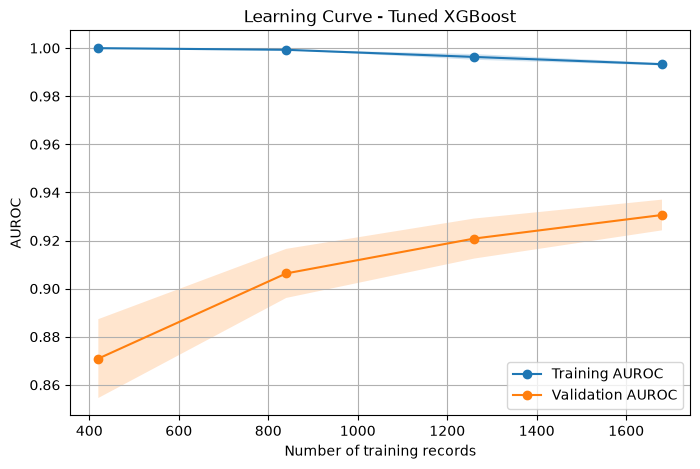

In [20]:
x_values = (
    learning_summary["Training Records"]["mean"].to_numpy()
)

train_mean = (
    learning_summary["Training AUROC"]["mean"].to_numpy()
)

train_std = (
    learning_summary["Training AUROC"]["std"].to_numpy()
)

val_mean = (
    learning_summary["Validation AUROC"]["mean"].to_numpy()
)

val_std = (
    learning_summary["Validation AUROC"]["std"].to_numpy()
)

plt.figure(figsize=(8, 5))

plt.plot(
    x_values,
    train_mean,
    marker="o",
    label="Training AUROC"
)

plt.plot(
    x_values,
    val_mean,
    marker="o",
    label="Validation AUROC"
)

plt.fill_between(
    x_values,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    x_values,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel("Number of training records")
plt.ylabel("AUROC")
plt.title("Learning Curve - Tuned XGBoost")
plt.legend()
plt.grid(True)
plt.show()

The learning curve shows that validation AUROC improves as the amount of training data increases, rising from about 0.87 with the smallest training set to about 0.93 with the full training set. At the same time, training AUROC remains very high, close to 1.0.

The gap between training and validation performance becomes smaller as more data is added, which suggests that additional training data could improve the model further. However, the remaining gap also indicates some overfitting. Therefore, more data may help, but improvements to the features, model regularization, or overall modelling approach could also improve generalization.

In [21]:
top_5_percent = int(np.floor(0.05 * len(y)))
number_of_positives = int(y.sum())

max_possible_challenge_score = (
    min(top_5_percent, number_of_positives)
    / number_of_positives
)

print("Total records:", len(y))
print("Positive records:", number_of_positives)
print("Records allowed in top 5%:", top_5_percent)
print(
    "Maximum possible Challenge score:",
    round(max_possible_challenge_score, 4)
)

Total records: 2100
Positive records: 1600
Records allowed in top 5%: 105
Maximum possible Challenge score: 0.0656
